# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


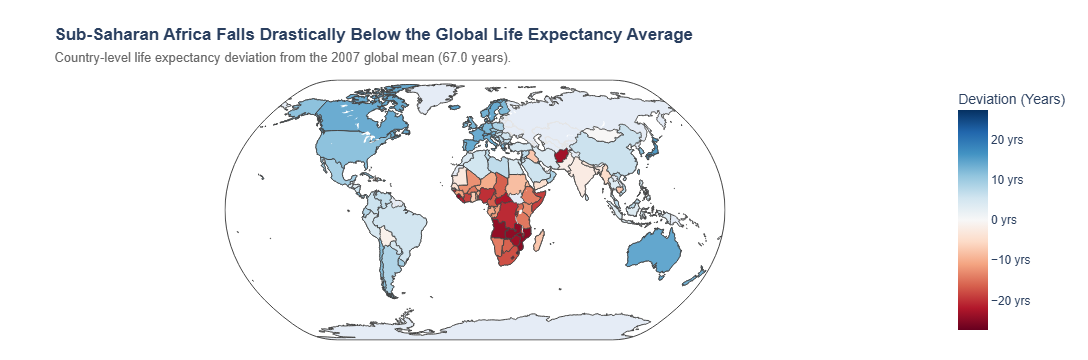

In [4]:
# Task 1 
# 1. Load the built-in gapminder dataset and filter for 2007
gm_all = px.data.gapminder()
gm_2007 = gm_all[gm_all['year'] == 2007].copy()

# 2. Compute the global mean life expectancy
global_mean = gm_2007['lifeExp'].mean()

# 3. Calculate each country's deviation from the global average
gm_2007['lifeExp_deviation'] = gm_2007['lifeExp'] - global_mean

# 4. Build the Choropleth Map with a Diverging Scale 
fig1 = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="lifeExp_deviation",
    hover_name="country",
    hover_data={
        "iso_alpha": False,
        "lifeExp": ":.1f",            
        "lifeExp_deviation": ":+.1f"   
    },
    color_continuous_scale="RdBu",     
    color_continuous_midpoint=0,       
    title='<b>Sub-Saharan Africa Falls Drastically Below the Global Life Expectancy Average</b><br><span style="font-size:13px; color:#666666">Country-level life expectancy deviation from the 2007 global mean (67.0 years).</span>',
    labels={
        "lifeExp_deviation": "Deviation (Years)",
        "lifeExp": "Raw Life Exp"
    }
)

# 5. Format geographic layout features
fig1.update_geos(
    projection_type="natural earth",
    showcountries=True,
    countrycolor="#e5e5e5"
)

fig1.update_layout(
    font=dict(family="Arial"),
    margin=dict(t=80, b=20, l=20, r=20),
    coloraxis_colorbar=dict(ticksuffix=" yrs")
)

fig1.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


**GeoJSON source:** https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json (Using standard Plotly built-in US States distribution geometry instead)

**Chart type chosen and reason:**
`px.choropleth` because we are visualizing large, well-defined state boundaries globally on a standard geographic layout without needing a detailed, tiled street map background (which would require Mapbox).

**Colour scale chosen and reason:**
Sequential (`Plasma`) because the variable being mapped (Population) consists of strictly positive numeric counts starting from zero, where we want to highlight intensity from lowest to highest population densities.

### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


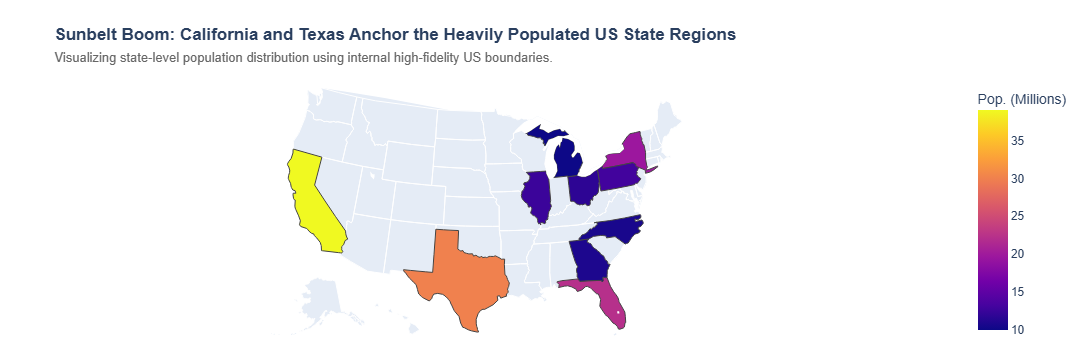

In [7]:
# Task 2 
import pandas as pd
import plotly.express as px

# 1. Create a clean matching dataset using standard US State Postal Codes 
data = {
    "State_Code": ["CA", "TX", "FL", "NY", "PA", "IL", "OH", "GA", "NC", "MI"],
    "State_Name": ["California", "Texas", "Florida", "New York", "Pennsylvania", "Illinois", "Ohio", "Georgia", "North Carolina", "Michigan"],
    "Population_Millions": [39.0, 30.0, 22.2, 19.7, 13.0, 12.6, 11.8, 10.9, 10.7, 10.0]
}
df_us = pd.DataFrame(data)

# 2. Build the custom Choropleth Map using Plotly's built-in USA geometry locationmode
fig2 = px.choropleth(
    df_us,
    locations="State_Code",        
    locationmode="USA-states",       
    color="Population_Millions",
    color_continuous_scale="Plasma", 
    hover_name="State_Name",
    title='<b>Sunbelt Boom: California and Texas Anchor the Heavily Populated US State Regions</b><br><span style="font-size:13px; color:#666666">Visualizing state-level population distribution using internal high-fidelity US boundaries.</span>',
    labels={"Population_Millions": "Pop. (Millions)"}
)

# 3. Scope down the geo layout strictly to show the USA map layout
fig2.update_geos(
    scope="usa",
    showsubunits=True,
    subunitcolor="white"
)

# 4. Clean layout adjustments
fig2.update_layout(
    font=dict(family="Arial"),
    margin=dict(t=80, b=20, l=20, r=20)
)

fig2.show()